# Bayesian Decision-Making for a Marketing Experiment
### From Beta priors to a \$-valued recommendation — regret, error rate, and the value of testing

**Author: Felipe Oliveira Franco · Data-Science Portfolio**

---

This notebook works a single decision problem *end to end*: two marketing strategies, a Beta prior over each one's signup rate, and a concrete business choice: commit now, or pay to run an experiment first?
The aim is not just to land on a recommendation but to make every step transparent and to show that the **math** and the **computation** agree at each stage.

What it demonstrates:

| Theme | What you'll see |
|---|---|
| **Conjugate Bayesian modelling** | Beta priors over signup rates, updated in closed form by Beta–Binomial conjugacy |
| **Decision theory** | **Expected regret**, and why it coincides here with the higher-mean rule |
| **Quantifying error** | The probability of committing to the **wrong** strategy without a test |
| **Value of information** | The **\$ value of running the experiment**, by Monte-Carlo over the full process |

> **Note.** The scenario is fictional but realistic; the numbers are chosen to illustrate the methods. The structure (two arms, Beta priors, a regret analysis, and the value of experimentation) is a standard pattern in Bayesian decision-making.

**To run:** `numpy`, `scipy`, `matplotlib`, `pandas`. No MCMC is needed here, the Beta–Binomial model is conjugate, so the posteriors are exact and the only sampling is the Monte-Carlo used to value the experiment. A global random seed is set for reproducibility.

---

## 1. The business problem

The marketing team has identified a population of **20,000 businesses** the company has never mailed before, but which recent data suggest are good signup prospects. The team worries that the **standard** mailing will not land well with this segment, so they have built a **novel** mailing strategy and want to know whether it is worth adopting.

A test is planned. **1,000 businesses per arm** (2,000 in total) will be assigned at random to the two strategies. Once the results are in, the **single** better-performing strategy will be rolled out to the remaining **18,000** businesses, where "better" means the arm with the **greater posterior-mean** $P(\text{signup})$.

The running cost of either strategy is the same, and every signup is worth **USD 150**. Before any data, the analysts propose these Beta priors for the two signup rates:

$$
\begin{aligned}
P(\text{signup}\mid\text{standard}) &\sim \text{Beta}(\alpha=32,\ \beta=368)\\[4pt]
P(\text{signup}\mid\text{novel})    &\sim \text{Beta}(\alpha=5,\ \beta=50)
\end{aligned}
$$

**The questions.**

- **(a)** Minimising expected regret, if you had to choose **without** running a test, which strategy would you pick?
  - **(i)** What considerations *other* than regret (or the higher prior-mean rule) might inform that choice?
- **(b)** What percentage of the time would that blind choice be the **wrong** one?
- **(c)** What is the prior expected value to the company, in USD over all 20,000 businesses, of:
  - **(i)** assigning all 20,000 to the standard strategy?
  - **(ii)** assigning all 20,000 to the novel strategy?
  - **(iii)** running the experiment?

---

Before beginning the analysis, we import the required libraries and define the priors, the signup value, and the population sizes used throughout the notebook.

In [1]:
# - Libraries -------------------------------------------------------
import numpy as np                                  # arrays, RNG, vectorised math
import pandas as pd                                 # tabular summaries (used later)
import matplotlib.pyplot as plt                     # plotting
from scipy.stats import beta, binom, gaussian_kde   # Beta priors/posteriors, Binomial test likelihood

# - Plotting and palette --------------------------------------------
# Wong colour-blind-safe palette; one role colour reused across every figure.
PALETTE = {"standard": "#0072B2", "novel": "#D55E00", "experiment": "#009E73",
           "accent": "#CC79A7", "grey": "#999999"}
plt.rcParams.update({
    "figure.figsize": (15, 7),
    "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
})

# - Reproducibility -------------------------------------------------
# A fixed seed makes the Monte-Carlo estimates (regret, P(wrong), value of the test) reproducible.
seed = 7

# - Priors (chosen by the analysts before the test) -----------------
# Beta(alpha, beta) on each strategy's signup probability p.
A_STD, B_STD = 32, 368       # standard strategy: strong, well-informed prior (pseudo-count 400)
A_NOV, B_NOV = 5, 50         # novel strategy:    weak, uncertain prior     (pseudo-count 55)
print(f"standard ~ Beta({A_STD}, {B_STD}): mean = {A_STD/(A_STD+B_STD):.4f}, sd = {beta.std(A_STD, B_STD):.4f}")
print(f"novel    ~ Beta({A_NOV}, {B_NOV}): mean = {A_NOV/(A_NOV+B_NOV):.4f}, sd = {beta.std(A_NOV, B_NOV):.4f}")

# - Business constants ----------------------------------------------
VALUE     = 150              # $ value of one signup
N_TOTAL   = 20_000           # businesses in the target population
N_PER_ARM = 1_000            # test customers assigned to EACH arm
N_TEST    = 2 * N_PER_ARM    # total test customers (both arms)
N_REMAIN  = N_TOTAL - N_TEST # businesses rolled out to the winning arm
print(f"\nValue per signup: USD {VALUE}")
print(f"Population: {N_TOTAL:,} businesses  ->  test {N_TEST:,} ({N_PER_ARM:,}/arm), "
      f"remaining {N_REMAIN:,} to the winner")

# - Ready -----------------------------------------------------------
print("\nAll set: priors and business constants are loaded. Ready to run the analysis.")

standard ~ Beta(32, 368): mean = 0.0800, sd = 0.0135
novel    ~ Beta(5, 50): mean = 0.0909, sd = 0.0384

Value per signup: USD 150
Population: 20,000 businesses  ->  test 2,000 (1,000/arm), remaining 18,000 to the winner

All set: priors and business constants are loaded. Ready to run the analysis.


## Solution

We take the four questions in turn. Parts (a) and (b) live entirely in the **prior**, they ask what we should do, and how often we would be wrong, *before* collecting any data. Part (c) assigns a monetary value to each course of action, and in (c)(iii) we have to model the experiment itself: a Bayesian update on each arm followed by a selection rule.

Before we begin, let's examine the prior distributions, which are modeled using Beta distributions.

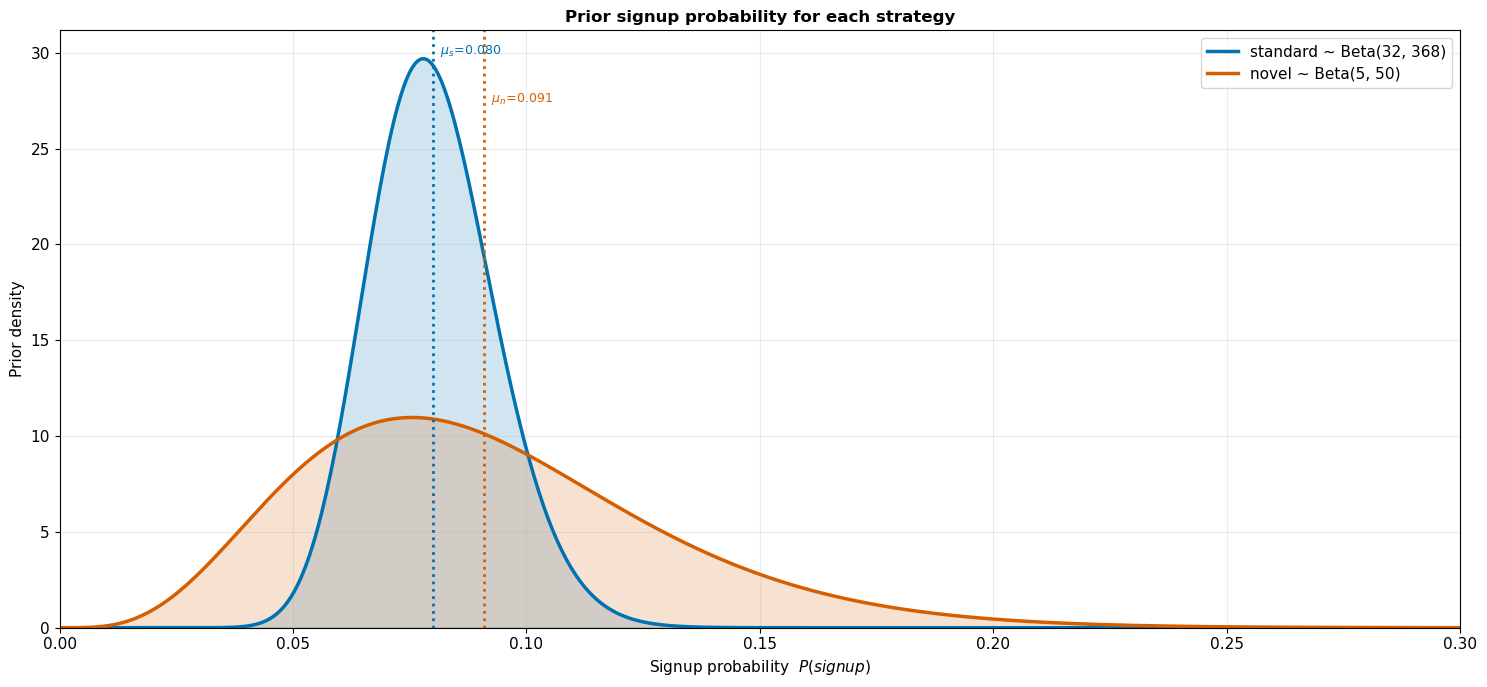

standard: mean = 0.0800, sd = 0.0135
novel   : mean = 0.0909, sd = 0.0384


In [3]:
# - Prior signup probability for each strategy -----------------------

# Data: Beta densities on a shared probability grid, plus the prior means
x = np.linspace(0, 0.30, 600)
dens_std = beta.pdf(x, A_STD, B_STD)
dens_nov = beta.pdf(x, A_NOV, B_NOV)
m_std, m_nov = A_STD/(A_STD+B_STD), A_NOV/(A_NOV+B_NOV)

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Density curves
ax.plot(x, dens_std, color=PALETTE["standard"], lw=2.5, label=f"standard ~ Beta({A_STD}, {B_STD})")
ax.fill_between(x, dens_std, color=PALETTE["standard"], alpha=0.18)
ax.plot(x, dens_nov, color=PALETTE["novel"], lw=2.5, label=f"novel ~ Beta({A_NOV}, {B_NOV})")
ax.fill_between(x, dens_nov, color=PALETTE["novel"], alpha=0.18)

# Reference lines at the prior means
ax.axvline(m_std, color=PALETTE["standard"], ls=":", lw=2)
ax.axvline(m_nov, color=PALETTE["novel"], ls=":", lw=2)
ax.text(m_std, ax.get_ylim()[1]*0.96, f"  $\\mu_s$={m_std:.3f}", color=PALETTE["standard"], fontsize=9)
ax.text(m_nov, ax.get_ylim()[1]*0.88, f"  $\\mu_n$={m_nov:.3f}", color=PALETTE["novel"], fontsize=9)

# Title and labels
ax.set(title="Prior signup probability for each strategy",
       xlabel="Signup probability $P(signup)$", ylabel="Prior density")

# Legend
ax.legend(frameon=True); ax.margins(x=0); ax.set_ylim(bottom=0)

# Display
fig.tight_layout(); plt.show()

print(f"standard: mean = {m_std:.4f}, sd = {beta.std(A_STD, B_STD):.4f}")
print(f"novel   : mean = {m_nov:.4f}, sd = {beta.std(A_NOV, B_NOV):.4f}")

The standard prior is highly concentrated around a conversion rate of 8%, reflecting strong prior information equivalent to 400 pseudo-observations ($\alpha_s+\beta_s$). In contrast, the novel prior is centred at about 9% but is substantially more dispersed, corresponding to only 55 pseudo-observations ($\alpha_n+\beta_n$). Although the novel arm has a higher prior mean, its greater uncertainty leads to substantial overlap between the two distributions. This trade-off between expected performance and uncertainty is a central feature of the analysis.

### (a) The regret-minimising choice

A $\text{Beta}(\alpha,\beta)$ prior over a rate $p$ has

$$
\mathbb{E}[p]=\frac{\alpha}{\alpha+\beta},\qquad
\operatorname{Var}(p)=\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)},
$$

so the prior means are $\mathbb{E}[p_{\text{std}}]=32/400=0.0800$ and $\mathbb{E}[p_{\text{nov}}]=5/55=0.0909$. The novel strategy has the higher mean, but its prior is far more spread out: its pseudo-count $\alpha_n+\beta_n=55$ is a fraction of the standard's $400$, so we are much less sure of it ($\text{sd}\approx 0.038$ against $\approx 0.014$).

Each signup is worth $V= 150$, so the per-business reward of a strategy is $r_X=p_X V$, and the **regret** of committing to a strategy is the value forgone versus whichever arm turns out better:

$$
\rho_{\text{std}}=V\,\max\{0,\ p_{\text{nov}}-p_{\text{std}}\},\qquad
\rho_{\text{nov}}=V\,\max\{0,\ p_{\text{std}}-p_{\text{nov}}\}.
$$

Minimising expected regret is the same as maximising expected reward, because $\mathbb{E}[\rho_X]=\mathbb{E}[r^\star]-\mathbb{E}[r_X]$ and the ideal reward $\mathbb{E}[r^\star]$ is common to both choices. Their difference is therefore governed only by the prior means,

$$
\mathbb{E}[\rho_{\text{std}}]-\mathbb{E}[\rho_{\text{nov}}]
=V\big(\mathbb{E}[p_{\text{nov}}]-\mathbb{E}[p_{\text{std}}]\big)
=150\,(0.0909-0.080)\approx \$1.64>0,
$$

so the standard strategy carries the **higher** expected regret. While the ordering of the strategies is already determined by their expected rewards, a Monte Carlo simulation allows us to estimate the expected regret itself. We therefore draw samples from the two prior distributions and compute the average value lost when the chosen arm is outperformed by the alternative.

expected regret (standard) = USD 3.255 per business
expected regret (novel)    = USD 1.617 per business


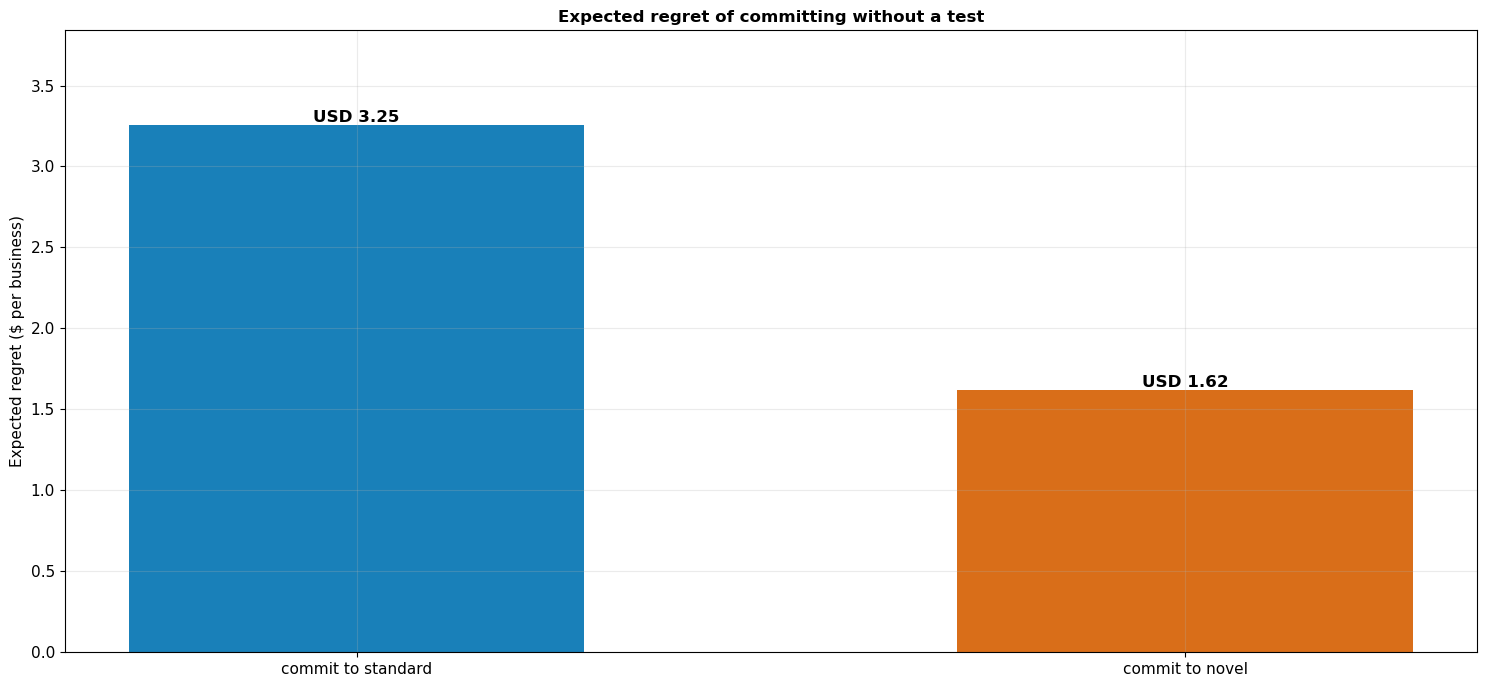

In [5]:
# - Expected regret of committing without a test --------------------

# Data: draw from each prior, then average the forgone value under each commitment
rng = np.random.default_rng(seed)
N = 10_000_000
p_std = rng.beta(A_STD, B_STD, N)
p_nov = rng.beta(A_NOV, B_NOV, N)
regret_std = VALUE * np.maximum(0, p_nov - p_std).mean()   # committed to standard, novel was better
regret_nov = VALUE * np.maximum(0, p_std - p_nov).mean()   # committed to novel, standard was better
print(f"expected regret (standard) = USD {regret_std:.3f} per business")
print(f"expected regret (novel)    = USD {regret_nov:.3f} per business")

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Bars
labels = ["commit to standard", "commit to novel"]
vals   = [regret_std, regret_nov]
bars = ax.bar(labels, vals, color=[PALETTE["standard"], PALETTE["novel"]], width=0.55, alpha=0.9)

# Annotations
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v, rf"USD {v:.2f}", ha="center", va="bottom", fontsize=12, weight="bold")

# Title and labels
ax.set(title="Expected regret of committing without a test",
       ylabel=r"Expected regret (\$ per business)")
ax.set_ylim(0, max(vals)*1.18)

# Display
fig.tight_layout(); plt.show()

**Answer (a).** Choose the **novel** strategy. Its expected regret is about **USD 1.62 per business** against **USD 3.25** for the standard strategy, a gap of USD 1.64, the USD 150 signup value times the 1-percentage-point difference in prior means. Equivalently, it is the arm with the higher prior expected signup rate (9.09% vs 8.00%), so minimising expected regret coincides here with the "highest expected $P(\text{signup})$".

### (a)(i) Other considerations

Expected regret (equivalently, the higher mean) collapses each strategy to a single number and ignores how *uncertain* that number is. Other things one could weigh:

- **Uncertainty and risk.** The novel prior is over two times wider (sd ≈ 0.0384 vs 0.0135). Its higher mean comes with real downside, the true rate could plausibly sit *below* the standard arm's. A risk-averse decision-maker might prefer the safer, better-understood standard arm, or penalise variance explicitly.
- **Probability of being right.** The means differ by less than the novel arm's spread, so the chance the blind choice is *wrong* is substantial, quantified in (b).
- **Worst-case / downside.** One could compare a low quantile of each prior (say the 5th percentile) rather than the mean, to protect against bad outcomes instead of chasing the average.
- **Value of information.** Precisely because the novel arm is so uncertain, a test is highly informative. The cost of committing blind is large *because* we know so little, which is what part (c) prices.

### (b) How often would the blind choice be wrong?

From (a) the commitment is to the **novel** arm. That call is *wrong* exactly when the strategy we picked is not in fact the better one, i.e. when the standard arm's true signup rate is the higher of the two:

$$
P(\text{wrong}) = P\big(p_{\text{std}} > p_{\text{nov}}\big),
$$

the prior mass where the standard arm beats the novel arm. The difference of two Beta variables has no elementary closed form, so we read it straight off the same prior draws used for the regret.

P(wrong) = P(p_std > p_nov) = 0.4327  (43.3%)


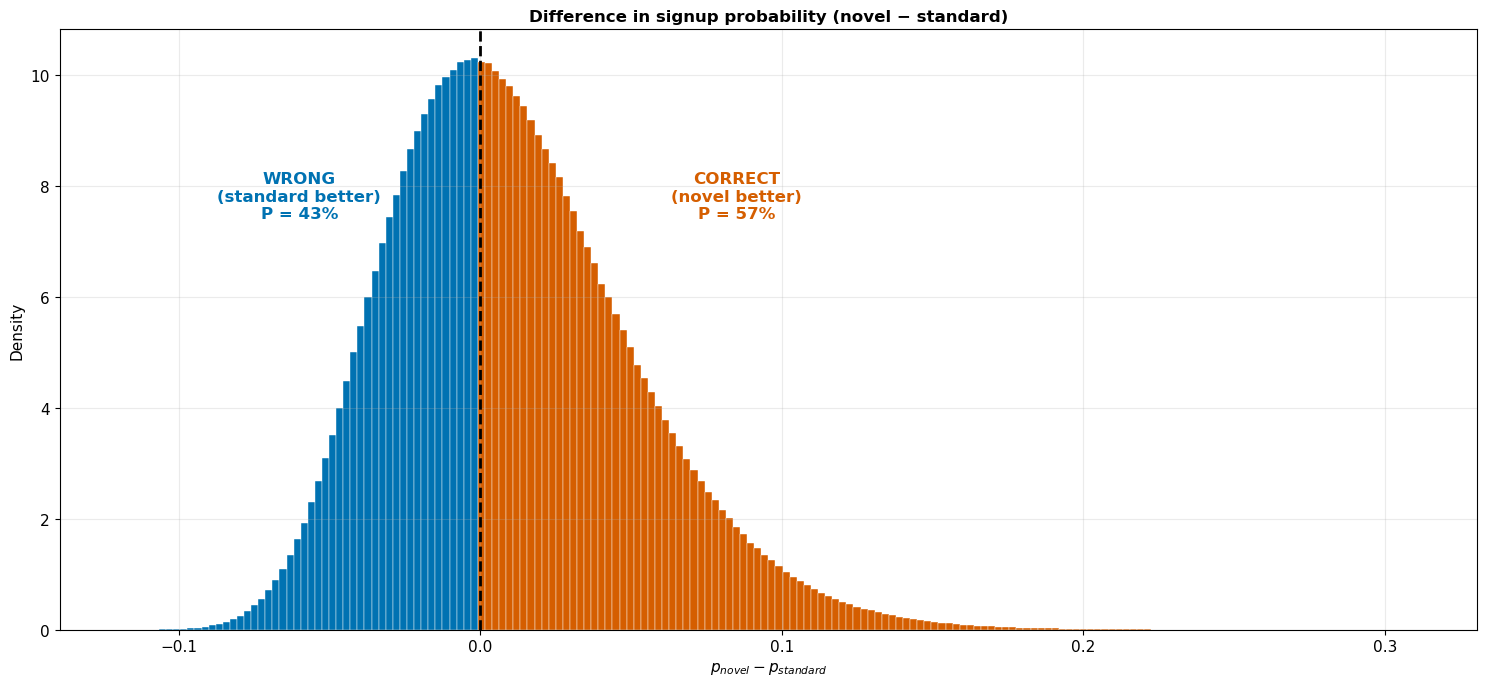

In [8]:
# - Probability of committing to the wrong strategy -----------------

# Data: a wrong decision = the standard arm is actually the better one
p_wrong = (p_std > p_nov).mean()
print(f"P(wrong) = P(p_std > p_nov) = {p_wrong:.4f}  ({p_wrong:.1%})")

# Distribution of the difference (novel - standard); blue = standard better (wrong), orange = novel better
delta = p_nov - p_std
counts, edges = np.histogram(delta, bins=200, density=True)
centers = (edges[:-1] + edges[1:]) / 2
colors = [PALETTE["standard"] if c < 0 else PALETTE["novel"] for c in centers]

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Histogram
ax.bar(centers, counts, width=(edges[1]-edges[0]), color=colors, edgecolor="white", linewidth=0.3, align="center")

# Reference line at zero
ax.axvline(0, color="black", ls="--", lw=2)

# Annotations
top = counts.max()
ax.text(-0.06, top*0.72, f"WRONG\n(standard better)\nP = {p_wrong:.0%}",
        color=PALETTE["standard"], ha="center", fontsize=12, weight="bold")
ax.text(0.085, top*0.72, f"CORRECT\n(novel better)\nP = {1-p_wrong:.0%}",
        color=PALETTE["novel"], ha="center", fontsize=12, weight="bold")

# Title and labels
ax.set(title="Difference in signup probability (novel − standard)",
       xlabel="$p_{novel} − p_{standard}$", ylabel="Density")
ax.margins(x=0)

# Display
fig.tight_layout()
plt.show()

**Answer (b).** About **43%** ($P(p_{\text{std}}>p_{\text{nov}})\approx 0.433$).

Committing to the novel strategy without a test would be the wrong call about **43%** of the time, better than a coin flip but not by much. The reason is exactly the overlap seen in the prior plot: although the novel arm has the higher mean, its prior is so wide that a large slice of its mass falls below the standard arm's tightly-known rate.

### (c)(i)–(ii) Value of committing to a single strategy

If every business in a group of size $M$ is assigned one strategy, the prior expected value is simply

$$
\text{Value} = M \times V \times \mathbb{E}[p],\qquad V=150,
$$

because each business signs up independently with probability $p$ and contributes $V$ when it does. With
$M=20{,}000$:

$$
V_{\text{std}} = 20000\times150\times\tfrac{32}{400}=\$240{,}000.00
\qquad
V_{\text{nov}} = 20000\times150\times\tfrac{5}{55}\approx\$272{,}727.27
$$

In [9]:
# - (c)(i)-(ii): expected value of committing all 20,000 to one arm --
V_std = N_TOTAL * VALUE * (A_STD / (A_STD + B_STD))
V_nov = N_TOTAL * VALUE * (A_NOV / (A_NOV + B_NOV))
print(f"(i)  all standard = USD {V_std:,.2f}")
print(f"(ii) all novel    = USD {V_nov:,.2f}")

(i)  all standard = USD 240,000.00
(ii) all novel    = USD 272,727.27


**Answer (c)(i)–(ii).** All-standard is worth **USD 240,000.00**, all-novel **USD 272,727.27** in prior expectation. Unsurprisingly, the higher-mean arm wins on the average, but as (b) showed, "on the average" hides a 43% chance that this ranking is backwards. That gap between the *expected* value and the *risk* is what the experiment is for.

### (c)(iii) Value of running the experiment

Running the test splits the 20,000 businesses into two groups:

- **2,000 test customers** (1,000 per arm) sign up at their arms' true rates during the test;
- **18,000 remaining** are all served the *winning* arm, the one with the greater **posterior-mean** $P(\text{signup})$ after the test.

So the expected value is

$$
V_{\text{exp}}
=\underbrace{V\,\mathbb{E}[y_{\text{std}}+y_{\text{nov}}]}_{\text{test } (2{,}000)}
\;+\;\underbrace{18000\,V\,\mathbb{E}[p_{\text{chosen}}]}_{\text{remaining } (18{,}000)} .
$$

The **test term** is closed form: $V\big(1000\,\mathbb{E}[p_{\text{std}}]+1000\,\mathbb{E}[p_{\text{nov}}]\big)
=150\,(32/400+5/55)\approx\$25{,}636.36$. The **remaining term** depends on the random test outcome through the selection
rule, so we need the posterior of each arm.

**Beta–Binomial updating: from prior to posterior.** Before turning to the code, it is worth seeing exactly how the test reshapes our belief about a single arm, since the entire value of the experiment flows from it. We begin with a prior over that arm's unknown signup rate $p_X$ ($X$ could be standard or novel strategy), we observe how many of the $n=1000$ test customers signed up, and Bayes' theorem tells us how to fold the two together into an updated belief, the **posterior**:

$$
\underbrace{p(p_X\mid y_X)}_{\text{posterior}}
=\frac{\overbrace{p(p_X)}^{\text{prior}}\ \overbrace{p(y_X\mid p_X)}^{\text{likelihood}}}{\underbrace{p(y_X)}_{\text{evidence}}}
\;\propto\; p(p_X)\,p(y_X\mid p_X).
$$

The denominator $p(y_X)$ does not depend on $p_X$, it is only the constant that makes the posterior integrate to one, so to find the *shape* of the posterior we can drop it and track proportionality alone.

*The prior* is the analyst's function

$$
p(p_X)\propto p_X^{\,\alpha_X-1}(1-p_X)^{\,\beta_X-1}.
$$

*The likelihood is Binomial.* Each of the $n$ test customers on an arm independently either signs up (with probability $p_X$) or does not, a single Bernoulli trial, so the total number of signups $y_X$ is a sum of $n$ such trials, which by definition is $\text{Binomial}(n,p_X)$:

$$
p(y_X\mid p_X)=\binom{n}{y_X}\,p_X^{\,y_X}(1-p_X)^{\,n-y_X}.
$$

Here too the combinatorial factor $\binom{n}{y_X}$ carries no $p_X$, so it folds into the proportionality constant.

*Multiplying* prior and likelihood and collecting the powers of $p_X$ and $(1-p_X)$:

$$
p(p_X\mid y_X)\;\propto\;
\underbrace{p_X^{\,\alpha_X-1}(1-p_X)^{\,\beta_X-1}}_{\text{prior}}\cdot
\underbrace{p_X^{\,y_X}(1-p_X)^{\,n-y_X}}_{\text{likelihood}}
= p_X^{\,(\alpha_X+y_X)-1}(1-p_X)^{\,(\beta_X+n-y_X)-1}.
$$

The result has exactly the same algebraic form as the prior, a Beta kernel, only with shifted exponents. This is what it means for the Beta prior to be **conjugate** to the Binomial likelihood: the posterior stays in the Beta family, and updating reduces to bookkeeping on its two parameters,

$$
p(p_X \mid y_X ) \;\sim\; \text{Beta}\big(\alpha_X+y_X,\ \beta_X+n-y_X\big).
$$

In words: **add the signups to $\alpha$ and the non-signups to $\beta$.** This is why $\alpha$ and $\beta$ are read as *pseudo-counts* of prior successes and failures, the data simply add real counts on top of them.

*The posterior mean* is the quantity the selection rule actually compares:

$$
\hat p_X=\mathbb{E}[p_X\mid y_X]=\frac{\alpha_X+y_X}{\alpha_X+\beta_X+n}.
$$

It has a revealing form, a **precision-weighted average of the prior mean and the observed rate**:

$$
\hat p_X=\underbrace{\frac{\alpha_X+\beta_X}{\alpha_X+\beta_X+n}}_{\text{weight on prior}}\cdot\frac{\alpha_X}{\alpha_X+\beta_X}
\;+\;\underbrace{\frac{n}{\alpha_X+\beta_X+n}}_{\text{weight on data}}\cdot\frac{y_X}{n}.
$$

The prior carries weight equal to its pseudo-count $\alpha_X+\beta_X$, and the data carry weight $n$. That makes the asymmetry between the two arms concrete. The standard prior has a pseudo-count of 400, so against $n=1000$ test customers the prior and the data have comparable pull and the estimate moves only moderately. The novel prior has just 55, so the same 1000 customers swamp it, the test is far more informative about the novel arm, which is precisely the arm we were most unsure about.

Substituting the priors and $n=1000$,

$$
\hat p_{\text{std}}=\frac{32+y_{\text{std}}}{1400},\qquad
\hat p_{\text{nov}}=\frac{5+y_{\text{nov}}}{1055},
$$

and we roll the winning arm, whichever has the larger $\hat p_X$, out to the remaining 18,000 businesses.

**Why this needs Monte-Carlo.** The winner depends on the random test outcomes $y_{\text{std}},y_{\text{nov}}$ through that comparison, and "take the larger of the two" is a *nonlinear* operation, so $\mathbb{E}[p_{\text{chosen}}]$ has no tidy closed form. We therefore value the experiment by simulating the whole process many times: draw a true rate for each arm from its prior, simulate one 1,000-per-arm test, form the two posterior means, pick the winner, and record the realised value, crediting both the test customers and the 18,000 remaining at their arms' *true* rates. Averaging over many such simulated experiments gives the expected value, and the spread of those outcomes (plotted below) measures the risk.

In [10]:
# - (c)(iii): value of the experiment, Monte-Carlo over the FULL process ----
# draw true rates -> simulate the 1,000+1,000 test -> pick the arm with the higher
# posterior mean -> credit the 18,000 remaining at that arm's TRUE rate.
# Averaging over outcomes is essential: the selection rule is nonlinear, so plugging
# in the expected counts would discard the entire value of the experiment.
rng = np.random.default_rng(seed)
M = 10_000_000
p_std = rng.beta(A_STD, B_STD, M)
p_nov = rng.beta(A_NOV, B_NOV, M)

# the test: 1,000 customers per arm
y_std = rng.binomial(N_PER_ARM, p_std)
y_nov = rng.binomial(N_PER_ARM, p_nov)

# posterior means, then pick the winner
pm_std = (A_STD + y_std) / (A_STD + B_STD + N_PER_ARM)
pm_nov = (A_NOV + y_nov) / (A_NOV + B_NOV + N_PER_ARM)
choose_novel = pm_nov > pm_std
p_chosen = np.where(choose_novel, p_nov, p_std)        # TRUE rate of the chosen arm

# value = test customers (2,000) + remaining (18,000) under the winner
test_value      = VALUE * (y_std + y_nov)
remaining_value = N_REMAIN * VALUE * p_chosen
total_value     = test_value + remaining_value
V_exp = total_value.mean()

# Display results
print(f"fraction choosing novel after the test = {choose_novel.mean():.3f}")
print(f"E[p_chosen]                            = {p_chosen.mean():.4f}")
print(f"test term  (2,000)  = USD {test_value.mean():,.2f}")
print(f"remaining  (18,000) = USD {remaining_value.mean():,.2f}")
print(f"experiment total    = USD {V_exp:,.2f}")

fraction choosing novel after the test = 0.570
E[p_chosen]                            = 0.1011
test term  (2,000)  = USD 25,635.09
remaining  (18,000) = USD 272,846.88
experiment total    = USD 298,481.97


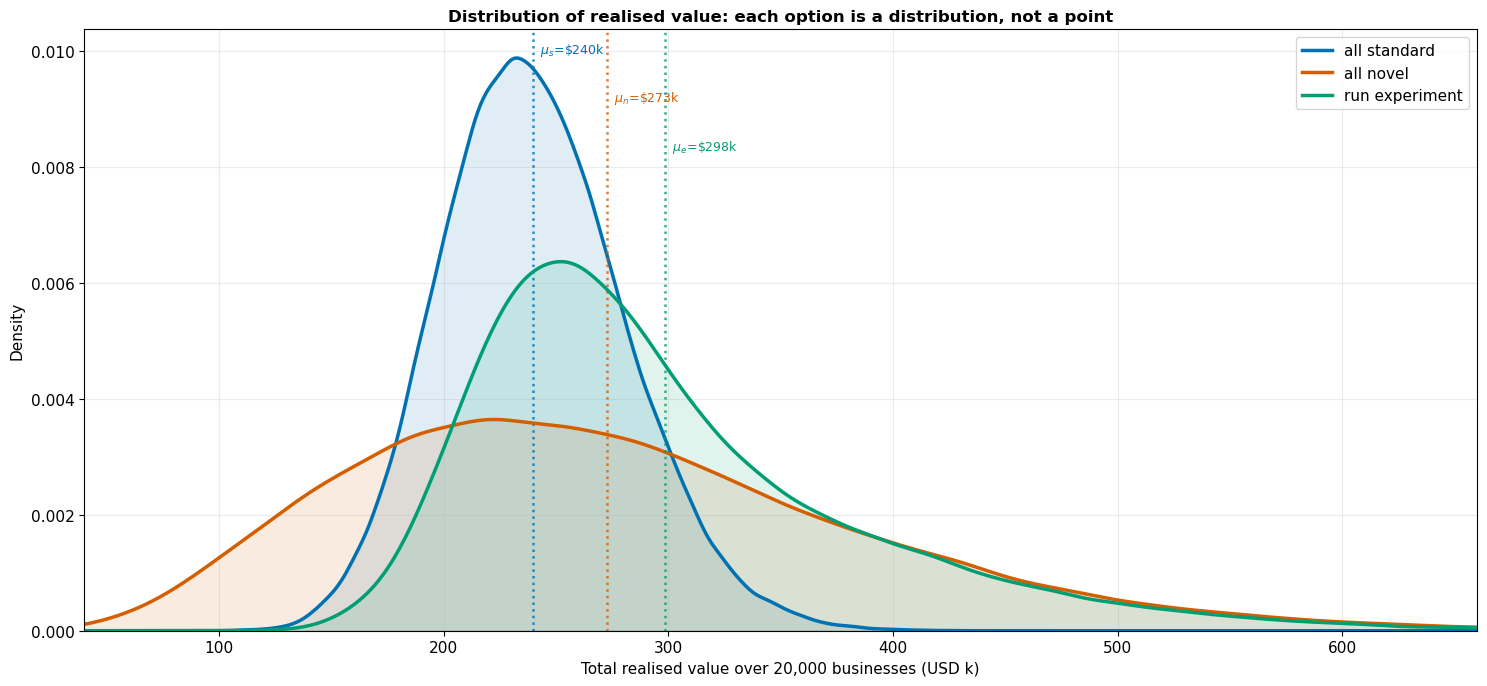

In [11]:
# - Distribution of realised value for each course of action ---------

# Data: realised value (in $k) for each option; commit options use the same true-rate draws
std_real = (N_TOTAL * VALUE * p_std) / 1000.0
nov_real = (N_TOTAL * VALUE * p_nov) / 1000.0
exp_real = total_value / 1000.0
xs = np.linspace(40, 660, 500)

# Figure setup
fig, ax = plt.subplots(figsize=(15, 7))

# Density curves (subsample for a quick smooth KDE) with mean reference lines
heights = [0.96, 0.88, 0.80]   # staggered label heights so the tags don't overlap
labels  = [r"$\mu_s$", r"$\mu_n$", r"$\mu_e$"]
for (data, col, name), h, lab in zip(
        [(std_real, PALETTE["standard"],  "all standard"),
         (nov_real, PALETTE["novel"],     "all novel"),
         (exp_real, PALETTE["experiment"], "run experiment")],
        heights, labels):
    dens = gaussian_kde(data[:120_000])(xs)
    ax.plot(xs, dens, color=col, lw=2.5,
            label=f"{name}")
    ax.fill_between(xs, dens, color=col, alpha=0.12)
    ax.axvline(data.mean(), color=col, ls=":", lw=1.8, alpha=0.8)
    ax.text(data.mean(), ax.get_ylim()[1]*h, rf"  {lab}=\${data.mean():.0f}k",
            color=col, fontsize=9)

# Title and labels
ax.set(title="Distribution of realised value: each option is a distribution, not a point",
       xlabel=r"Total realised value over 20,000 businesses (USD k)", ylabel="Density")

# Legend
ax.legend(frameon=True); ax.margins(x=0); ax.set_ylim(bottom=0); ax.set_xlim(40, 660)

# Display
fig.tight_layout()
plt.show()

**Answer (c)(iii).** Running the experiment is worth **≈ USD 298,500** in prior expectation: about **≈USD 25,635** of signups from the 2,000 test customers, plus **≈USD 272,846** from the 18,000 remaining served the winning arm, at an effective rate $\mathbb{E}[p_{\text{chosen}}]\approx 0.101$, *above either* prior mean, which is the whole point of testing.

Two things are worth stressing. First, this must be computed by **averaging value over the distribution of test outcomes**, not by plugging in the expected counts $(y_{\text{std}},y_{\text{nov}})=(80,91)$: the selection rule is nonlinear, and the plug-in simply re-picks novel and returns USD 272,727, the all-novel value, discarding the experiment's entire benefit. Second, the density plot shows *why* the experiment wins: it has both the **highest mean** and a **tighter spread than committing to novel** (sd ≈ USD 87k vs ≈ USD 115k), because the test hedges away the worst novel outcomes by reverting to standard whenever the data warrant it. The experiment buys roughly **USD 25,800 of expected value over the best blind choice**, and removes much of its risk for the price of 2,000 test mailings.

## Summary

The three courses of action, and the decision metrics behind them, in one place.

In [13]:
# - Results at a glance ---------------------------------------------
summary = pd.DataFrame({
    "option": ["All standard", "All novel", "Run experiment"],
    "effective E[p]": [A_STD/(A_STD+B_STD), A_NOV/(A_NOV+B_NOV), p_chosen.mean()],
    "expected value (USD)": [V_std, V_nov, V_exp],
    "realised sd (USD)": [std_real.std()*1000, nov_real.std()*1000, exp_real.std()*1000],
}).round({"effective E[p]": 4, "expected value (USD)": 0, "realised sd (USD)": 0})
print(summary.to_string(index=False))
print(f"\n(a) regret: standard USD {regret_std:.2f}/business vs novel USD {regret_nov:.2f}/business  -> choose NOVEL")
print(f"(b) P(wrong | commit to novel) = {p_wrong:.1%}")
summary

        option  effective E[p]  expected value (USD)  realised sd (USD)
  All standard          0.0800              240000.0            40636.0
     All novel          0.0909              272727.0           115265.0
Run experiment          0.1011              298482.0            87267.0

(a) regret: standard USD 3.25/business vs novel USD 1.62/business  -> choose NOVEL
(b) P(wrong | commit to novel) = 43.3%


,option,effective E[p],expected value (USD),realised sd (USD)
0,All standard,0.0800,240000.0,40636.0
1,All novel,0.0909,272727.0,115265.0
2,Run experiment,0.1011,298482.0,87267.0


**The story in one line.** The novel strategy has the higher prior mean signup rate (about 9% vs 8%), so on expected regret it is the blind pick, but its prior is nearly three times wider, and committing to it without a test would be wrong more than two times in five. Pricing the options over 20,000 businesses, all-standard is worth USD 240k and all-novel USD 273k, while **running the experiment is worth ≈USD 298k** , the most of the three, *and* with less risk than all-novel, because the test lets us back the winner and retreat to the safe arm when the novel one disappoints. The recommendation is therefore to **run the experiment**: for the cost of 2,000 test mailings it adds roughly USD 26k of expected value over the best blind choice and hedges away the novel arm's downside.

### Where I'd take this next
- **Optimal test size.** Treat USD 26k of expected gain against the cost of the test and sweep $n$ to find the test size that maximises net value (here the test is nearly free, so larger $n$ helps until the remaining pool shrinks).
- **Full posterior decision, not just the mean.** Select on $P(p_{\text{nov}}>p_{\text{std}}\mid\text{data})$ or on a risk-adjusted criterion (e.g. a low posterior quantile) rather than the posterior mean.
- **Unequal costs or values.** Fold a per-mailing cost or arm-specific signup value into the reward.
- **More arms / segments.** With several strategies or customer segments, a hierarchical model pools information across arms and shrinks noisy estimates toward a common baseline.

---
*Reproducibility: NumPy seed = 7; Monte-Carlo with 10,000,000 draws for the regret, error rate, and the value of the experiment.*